# DS4200 Homework 8

Due: Friday Mar 27th @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file included with the coding results and and two `png` files from the part 3 to Gradescope (this can also be done via the assignment on Canvas).  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the files to gradescope.

### Tips for success
- Start early
- Make use of Piazza
- Make use of Office hour
- Remember to use cells and headings to make the notebook easy to read (if a grader cannot find the answer to a problem, you will receive no points for it)
- Under no circumstances may one student view or share their ungraded homework or quiz with another student [(see also)](http://www.northeastern.edu/osccr/academic-integrity), though you are welcome to **talk about** (not show each other) the problems.

### Part 1 Explore the TX population and unemployment rate
#### Part 1.1 Prepare the geospatial data (10 points)

On Canvas, you will find a CSV file named `unemp.csv` containing **county-level unemployment rates and population data**. Use the county-level geospatial dataset provided in the lecture, `ne_10m_admin_2_counties`, to **merge** the two datasets. Then, extract the subset of data corresponding to **Texas** and create a **county-level map of Texas**. For the map, display **only the county boundaries**. Use **GeoPandas** to complete **Questions 1.1 through 1.3**.

> **Note:** Texas has 254 counties, more than any other U.S. state.


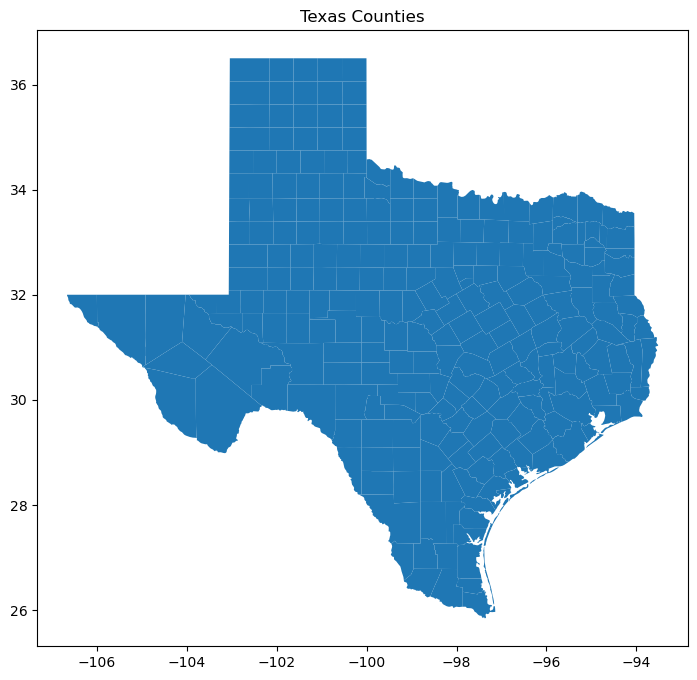

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

unemp = pd.read_csv('unemp.csv')

counties = gpd.read_file("https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_2_counties.zip")

counties['FIPS'] = counties['FIPS'].str.replace('US', '').astype(int)

merged = counties.merge(unemp, left_on='FIPS', right_on='fips')

texas = merged[merged['fips'] // 1000 == 48]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
texas.plot(ax=ax)
plt.title("Texas Counties")
plt.show()

#### Part 1.2 Choropleth maps and customization in Geopanda (5 points)

Make a **choropleth maps with unemployment rate**. Choose **another color map** from
https://matplotlib.org/stable/users/explain/colors/colormaps.html. Give a title to the figure (use `plt.title`) as well as a title to the legend. 


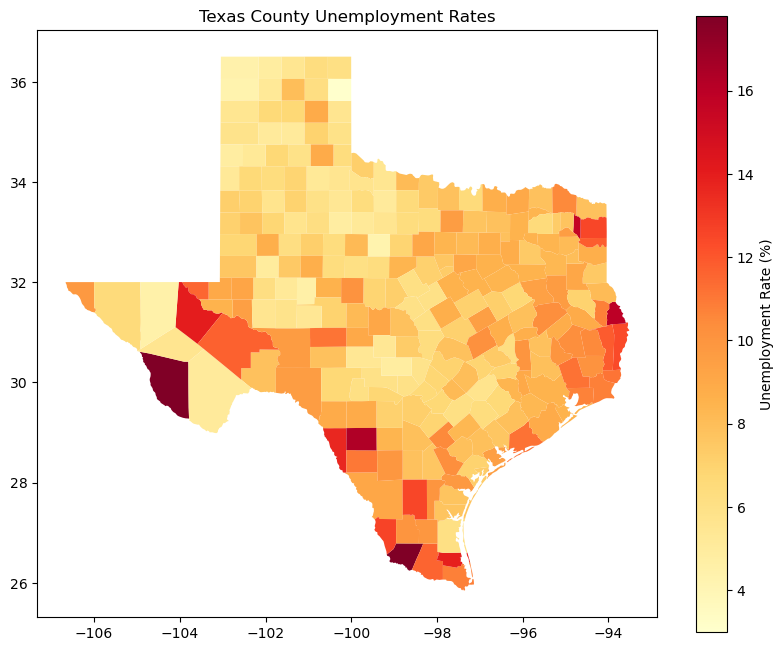

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
texas.plot(column='unemp', ax=ax, legend=True, cmap='YlOrRd',
           legend_kwds={'label': 'Unemployment Rate (%)'})
plt.title("Texas County Unemployment Rates")
plt.show()

#### Part 1.3 Handle the missing values (10 points)

Make a **copy** of your Texas dataset. Then, following the approach we used in lecture:

- Randomly select **30 counties** and set their **unemployment rate** values to `NaN` (missing). **Only run this line for once.**
- Re-plot the **choropleth map of unemployment rate** for Texas counties.
- Clearly distinguish missing-value counties by specifying:
  - a **fill color** for missing areas,
  - a **boundary (edge) color/linewidth**, and
  - a **hatch pattern** for missing areas.
- Add a **legend entry** indicating which counties have missing unemployment-rate values.

Choose a hatch pattern that is **different from the one used in the lecture notes**. You may refer to the hatch pattern options here: https://matplotlib.org/devdocs/gallery/shapes_and_collections/hatch_style_reference.html


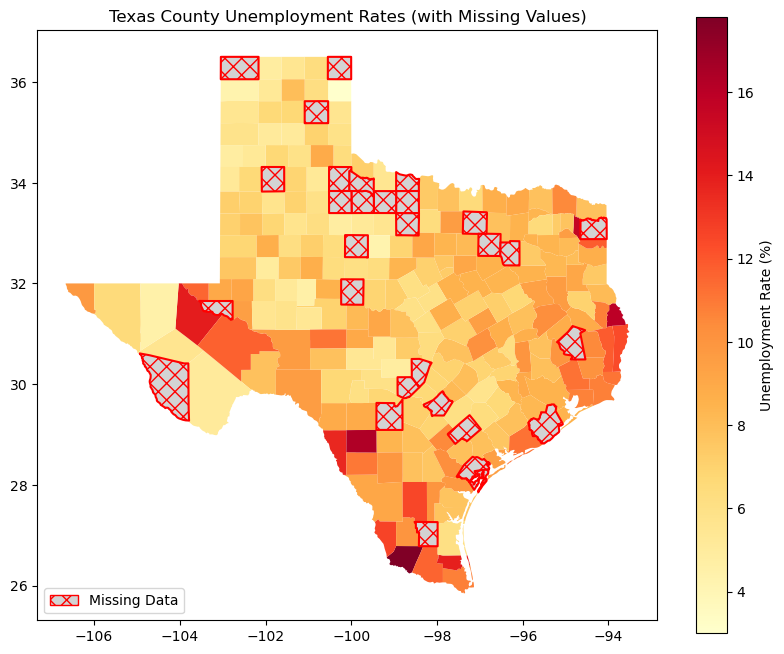

In [15]:
import numpy as np

texas_missing = texas.copy()
random_idx = texas_missing.sample(30).index
texas_missing.loc[random_idx, 'unemp'] = np.nan

texas_no_nan = texas_missing[texas_missing['unemp'].notna()]
texas_nan = texas_missing[texas_missing['unemp'].isna()]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

texas_no_nan.plot(column='unemp', ax=ax, legend=True, cmap='YlOrRd',
                  legend_kwds={'label': 'Unemployment Rate (%)'})

texas_nan.plot(ax=ax, color='lightgray', edgecolor='red', linewidth=1.5, hatch='xx')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='lightgray', edgecolor='red', hatch='xx', label='Missing Data')]
ax.legend(handles=legend_elements, loc='lower left')

plt.title("Texas County Unemployment Rates (with Missing Values)")
plt.show()

#### Part 1.4 Choropleth maps with Altair (5 points)

Now, recreate the **Texas county choropleth map** using **Altair**, using the **original Texas dataset (without missing values)**.

- Create a choropleth map where **fill color encodes the unemployment rate** using a **single-hue (sequential) color scheme**.
- Add a tooltip that shows **county name** and **unemployment rate**.
- Use the **`albersUsa` projection** for the map.


In [16]:
import altair as alt

texas_json = alt.Data(values=texas.__geo_interface__['features'])

chart = alt.Chart(texas_json).mark_geoshape().encode(
    color=alt.Color('properties.unemp:Q', 
                    scale=alt.Scale(scheme='oranges'),
                    legend=alt.Legend(title='Unemployment Rate (%)')),
    tooltip=[
        alt.Tooltip('properties.NAME:N', title='County'),
        alt.Tooltip('properties.unemp:Q', title='Unemployment Rate')
    ]
).project('albersUsa').properties(
    title='Texas County Unemployment Rates',
    width=700,
    height=500)

chart

alt.Chart(...)

#### Part 1.5 Symbol maps with Altair (10 points)

Add two new columns to your Texas GeoDataFrame to store the **centroid longitude and latitude** for each county. You may extract these values using:

- `gdf(Texas GeoDataFrame).geometry.centroid.x` for longitude
- `gdf(Texas GeoDataFrame).geometry.centroid.y` for latitude  

(You can ignore any warning messages generated by the centroid calculation.)

Then create a **two-layer map**:

- **Bottom layer:** a Texas county boundary map with **white fill** (and visible outlines).
- **Top layer:** a **circle mark** placed at each county’s centroid. Encode **population** using the **size** of the circles.
  - Add a tooltip on the circles that shows **county name** and **population**.

In [17]:
import warnings
warnings.filterwarnings('ignore')

texas['longitude'] = texas.geometry.centroid.x
texas['latitude'] = texas.geometry.centroid.y

texas_json = alt.Data(values=texas.__geo_interface__['features'])

base = alt.Chart(texas_json).mark_geoshape(
    fill='white',
    stroke='black',
    strokeWidth=0.5
).project('albersUsa')

points = alt.Chart(texas).mark_circle().encode(
    longitude='longitude:Q',
    latitude='latitude:Q',
    size=alt.Size('pop:Q', legend=alt.Legend(title='Population')),
    tooltip=[
        alt.Tooltip('NAME:N', title='County'),
        alt.Tooltip('pop:Q', title='Population')
    ]
).project('albersUsa')

(base + points).properties(
    title='Texas County Population',
    width=700,
    height=500)

alt.LayerChart(...)

#### Part 1.6 Interactive choropleth maps for both unemployment rate and population (10 points)

Design an **interactive choropleth map** of Texas counties in **Altair** with a **radio-button** control that lets the viewer choose which variable to visualize:

- **Unemployment rate**, or
- **Population**

Requirements:

- Use a **single choropleth map** of Texas counties where the **fill color** updates based on the selected variable.
- Add a tooltip that includes:
  - **County name**
  - **Selected variable name**
  - **Selected variable value**
- Use the **Natural Earth** projection.

**Note:** If your legend extends beyond the chart boundary, consider adjusting the legend position by adding something like the following to your `alt.Color(...)` encoding:

```python
legend=alt.Legend(orient='right', offset=-100)
```

In [18]:
variable_select = alt.binding_radio(
    options=['unemp', 'pop'],
    labels=['Unemployment Rate', 'Population'],
    name='Variable: '
)
selection = alt.param(name='variable', bind=variable_select, value='unemp')

texas_json = alt.Data(values=texas.__geo_interface__['features'])

chart = alt.Chart(texas_json).mark_geoshape().transform_calculate(
    display_value="variable == 'unemp' ? datum.properties.unemp : datum.properties.pop",
    county_name="datum.properties.NAME",
    selected_label="variable == 'unemp' ? 'Unemployment Rate' : 'Population'"
).encode(
    color=alt.Color('display_value:Q',
                    scale=alt.Scale(scheme='oranges'),
                    legend=alt.Legend(orient='right', offset=-100, title='Value')),
    tooltip=[
        alt.Tooltip('county_name:N', title='County'),
        alt.Tooltip('selected_label:N', title='Variable'),
        alt.Tooltip('display_value:Q', title='Value')
    ]
).add_params(
    selection
).project('naturalEarth1').properties(
    title='Texas Counties: Unemployment Rate & Population',
    width=700,
    height=500
)

chart

alt.Chart(...)

### Part 2: Tableau with unemployment data (10 points)

Now let’s recreate the **unemployment choropleth map** using **Tableau**. Connect the `unemp.csv` file to Tableau and complete the necessary **data cleaning** steps before creating any visualizations. Currently, the **FIPS codes** are interpreted as integers, which prevents Tableau from recognizing them correctly as geographic identifiers. Follow the steps below carefully. Once finished, publish your visualization to **Tableau Public** and paste the link here.

- Connect `unemp.csv` to Tableau.
- At the beginning, note that the **FIPS** field is treated as an integer and some values are not five digits. Create a **new calculated field** to convert the FIPS code into a 5-digit string (for example, converting `2115` to `"02115"`):
  
    RIGHT("00" + STR([Fips]), 5)


- Using a similar approach, create another calculated field that extracts the **state-level FIPS code** (the first two digits of the 5-digit FIPS code, e.g., `"02"` from `"02115"`).
- Assign the **geographical role** of **County** to the 5-digit FIPS code field.
- In a worksheet, create a **choropleth map** showing the unemployment rate for **Texas counties**. Use the 2-digit state FIPS code to filter the data.
- Edit the **figure title** and **legend title**, and customize the **color scheme** used in the legend.
- From the top menu, select **Map → Background Maps → Normal**. (Feel free to explore how the other background map options look.)
- Create a new **dashboard** and add the map worksheet to it.
- Set the legend to **Floating** and place it inside the map.
- Publish the dashboard to **Tableau Public** and paste the link to your visualization here.


https://public.tableau.com/app/profile/maggie.chen7459/viz/HW8_Texas_Unemployement/Dashboard1?publish=yes